# Exploratory Data Analysis

In [72]:
import sklearn
print(sklearn.__version__)

1.6.1


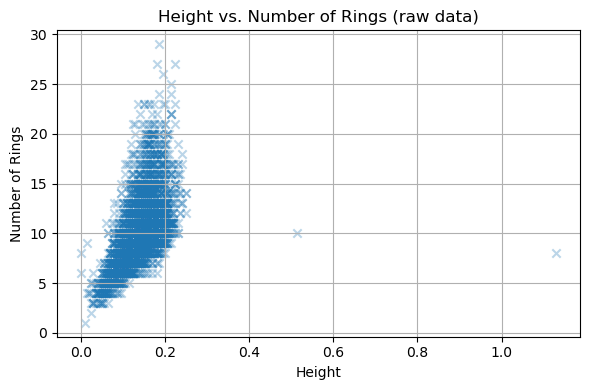

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Load dataset
file_path = "turtle-2.csv"
df = pd.read_csv(file_path)
df_unfitlered = df
# df = df[df["Height"] < 0.4].reset_index(drop=True)

## Assign features (X) and (y)
y = df['Rings']
X = df.drop(columns=['Rings'])

numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.drop('Rings')

# Creating scatter plots for each measurement against Rings
for feature in numerical_features:
    if feature in ["Height"]:
        plt.figure(figsize=(6, 4))
        plt.scatter(df[feature], df['Rings'], alpha=0.3, marker='x')
        plt.xlabel(feature)
        plt.ylabel("Number of Rings")
        title = f"{feature} vs. Number of Rings (raw data)"
        plt.title(title)
        plt.grid(True)
        plt.tight_layout()
        plt_name = re.sub(r'[^\w\.]', '_', title)
        plt.savefig(f"Figures/{plt_name}.png")
        plt.show()


In [40]:
print("Height > 0")
print((df_unfitlered[numerical_features] <= 0).sum())
print("\nHeight > 0.4")
print(df_unfitlered["Height"][df_unfitlered["Height"] > 0.4])


df = df[df["Height"] < 0.4].reset_index(drop=True)
df = df[df["Height"] > 0].reset_index(drop=True)

print("\nRemoved:", len(df_unfitlered)-len(df))
print("New n:", len(df))
## Re-assign features (X) and (y)
y = df['Rings']
X = df.drop(columns=['Rings'])

Height > 0
Length            0
Diameter          0
Height            2
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
dtype: int64

Height > 0.4
1417    0.515
2051    1.130
Name: Height, dtype: float64

Removed: 4
New n: 4173


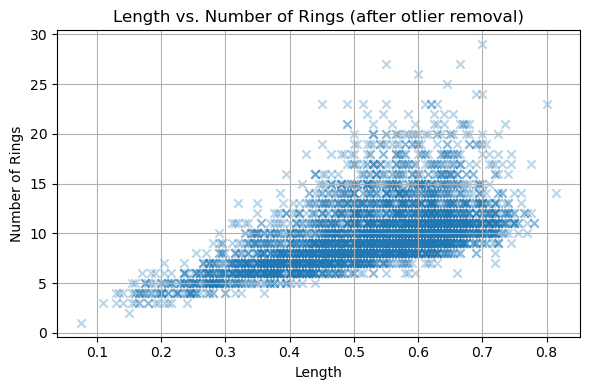

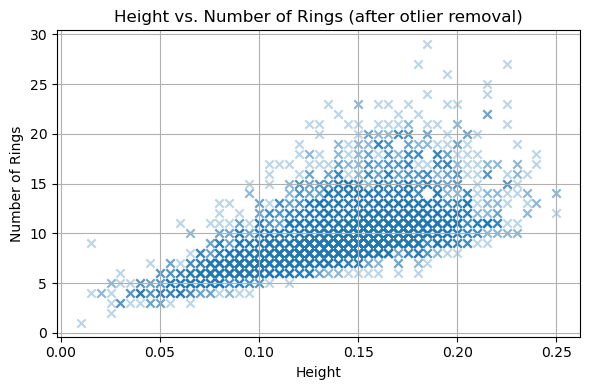

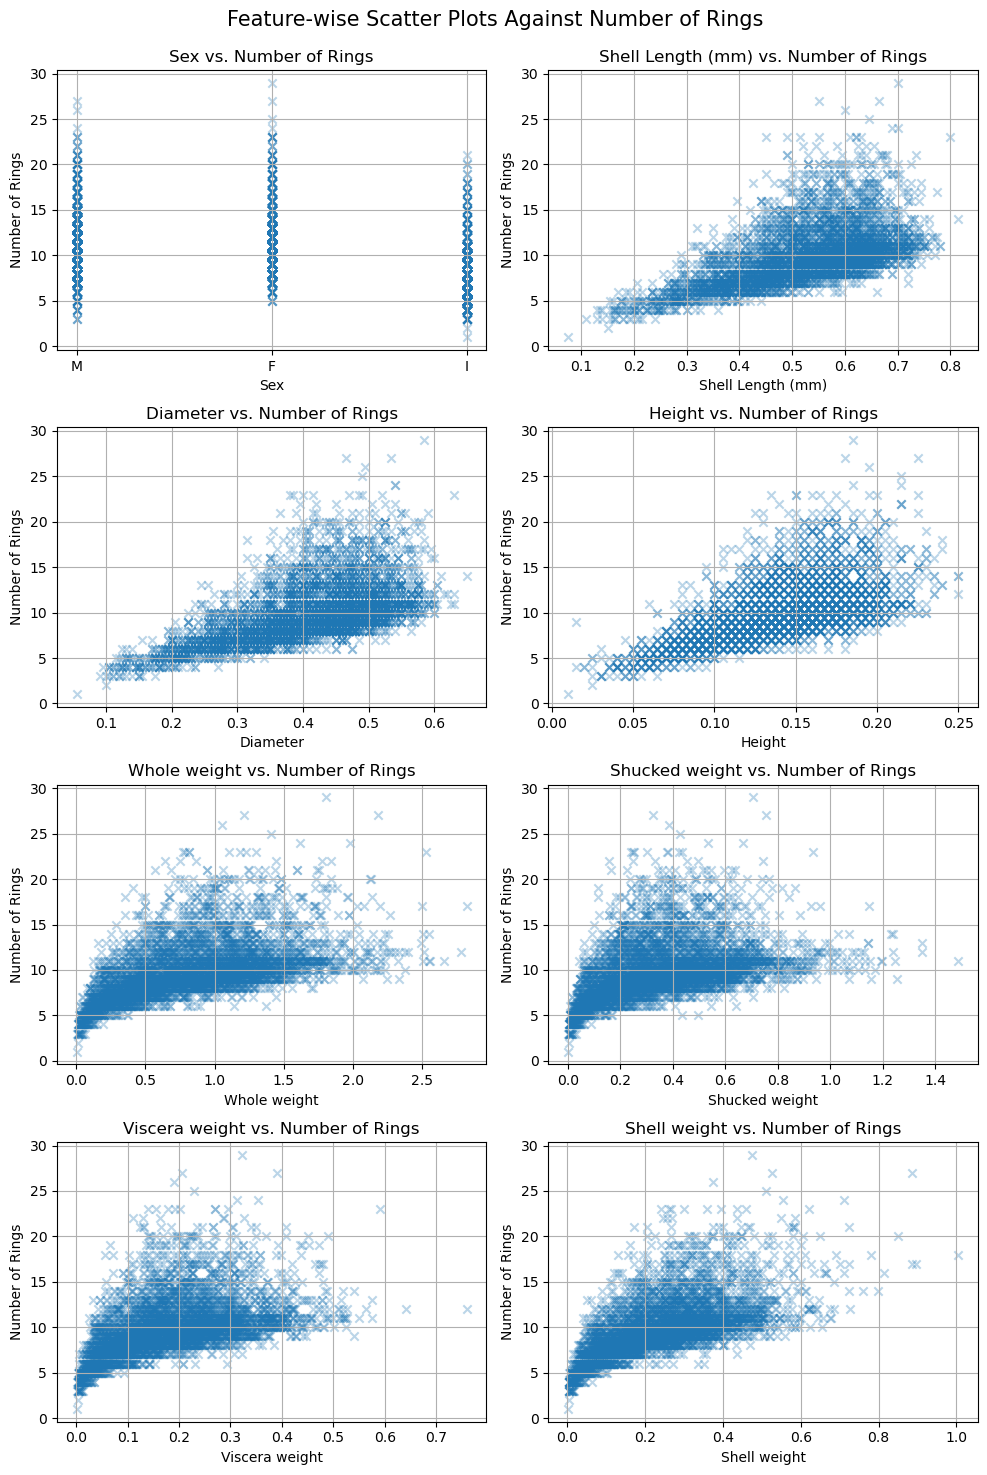

In [41]:
for feature in numerical_features:
    if feature in ["Length", "Height"]:
        plt.figure(figsize=(6, 4))
        plt.scatter(df[feature], df['Rings'], alpha=0.3, marker='x')
        plt.xlabel(feature)
        plt.ylabel("Number of Rings")
        title = f"{feature} vs. Number of Rings (after otlier removal)"
        plt.title(title)
        plt.grid(True)
        plt.tight_layout()
        plt_name = re.sub(r'[^\w\.]', '_', title)
        plt.savefig(f"Figures/{plt_name}.png")
        plt.show()


# More scatterplots for my own visualization
rows, cols = (4, 2)
fig, axes = plt.subplots(rows, cols, figsize=(10,15))
axes = axes.flatten()

for ax, feature in zip(axes, X):
    ax.scatter(df[feature], df['Rings'], alpha=0.3, marker='x')
    if feature == "Length":
        feature = "Shell Length (mm)"
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Rings")
    ax.set_title(f"{feature} vs. Number of Rings")
    ax.grid(True)

title = "Feature-wise Scatter Plots Against Number of Rings"
fig.suptitle(title, fontsize=15)
fig.tight_layout()
fig.subplots_adjust(top=0.94)

plt_name = re.sub(r'[^\w\.]', '_', title)
fig.savefig(f"Figures/{plt_name}.png")
plt.show()

## Summary Statistics and Correlations

In [42]:
# Basic descriptive statistics

desc_stats = df.describe().loc[['mean', 'std', 'min', 'max']]
print("Descriptive Statistics:\n", desc_stats)

Descriptive Statistics:
         Length  Diameter    Height  Whole weight  Shucked weight  \
mean  0.524038  0.407915  0.139256      0.828730        0.359304   
std   0.120061  0.099210  0.038378      0.489987        0.221705   
min   0.075000  0.055000  0.010000      0.002000        0.001000   
max   0.815000  0.650000  0.250000      2.825500        1.488000   

      Viscera weight  Shell weight      Rings  
mean        0.180595      0.238794   9.935538  
std         0.109525      0.139172   3.224861  
min         0.000500      0.001500   1.000000  
max         0.760000      1.005000  29.000000  


In [43]:
# Create latex for table that will be added into the paper

latex_table = df.describe().loc[['mean', 'std', 'min', 'max']].T.to_latex(float_format="%.3f", caption="Descriptive Statistics", label="tab:desc_stats")
print(latex_table)

\begin{table}
\caption{Descriptive Statistics}
\label{tab:desc_stats}
\begin{tabular}{lrrrr}
\toprule
 & mean & std & min & max \\
\midrule
Length & 0.524 & 0.120 & 0.075 & 0.815 \\
Diameter & 0.408 & 0.099 & 0.055 & 0.650 \\
Height & 0.139 & 0.038 & 0.010 & 0.250 \\
Whole weight & 0.829 & 0.490 & 0.002 & 2.825 \\
Shucked weight & 0.359 & 0.222 & 0.001 & 1.488 \\
Viscera weight & 0.181 & 0.110 & 0.001 & 0.760 \\
Shell weight & 0.239 & 0.139 & 0.002 & 1.005 \\
Rings & 9.936 & 3.225 & 1.000 & 29.000 \\
\bottomrule
\end{tabular}
\end{table}



In [44]:
import numpy as np

correlation_matrix = df.drop(columns=['Sex']).corr()
np.fill_diagonal(correlation_matrix.values, np.nan)

print("Min: ", correlation_matrix.min().min())
print("Max: ", correlation_matrix.max().max())
display(correlation_matrix)

Min:  0.42115592388147455
Max:  0.9867938707146229


,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
Length,NaN,0.986794,0.900868,0.925328,0.898129,0.903033,0.898363,0.556572
Diameter,0.986794,NaN,0.907187,0.925499,0.893330,0.899716,0.906026,0.574551
Height,0.900868,0.907187,NaN,0.888850,0.837485,0.866757,0.891857,0.610107
Whole weight,0.925328,0.925499,0.888850,NaN,0.969370,0.966290,0.955954,0.540621
Shucked weight,0.898129,0.893330,0.837485,0.969370,NaN,0.931831,0.883194,0.421156
Viscera weight,0.903033,0.899716,0.866757,0.966290,0.931831,NaN,0.908133,0.503977
Shell weight,0.898363,0.906026,0.891857,0.955954,0.883194,0.908133,NaN,0.628169
Rings,0.556572,0.574551,0.610107,0.540621,0.421156,0.503977,0.628169,NaN


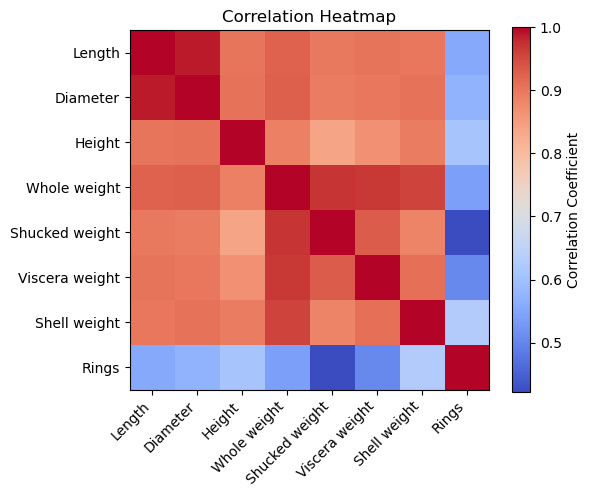

In [45]:
import numpy as np

# Correlation heatmap
correlation_matrix = df.drop(columns=['Sex']).corr()
plt.figure(figsize=(6,5))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label="Correlation Coefficient")
plt.xticks(ticks=np.arange(len(correlation_matrix.columns)), labels=correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(correlation_matrix.columns)), labels=correlation_matrix.columns)
title = "Correlation Heatmap"
plt.title(title)
plt.tight_layout()
plt_name = re.sub(r'[^\w\.]', '_', title)
plt.savefig(f"Figures/{plt_name}.png")
plt.show()

In [46]:
# Correlations sorted by strength
correlation_table = correlation_matrix['Rings'].sort_values(ascending=False)
print(correlation_table)

Rings             1.000000
Shell weight      0.628169
Height            0.610107
Diameter          0.574551
Length            0.556572
Whole weight      0.540621
Viscera weight    0.503977
Shucked weight    0.421156
Name: Rings, dtype: float64


In [47]:
# Correlations sorted by strength
correlation_table_latex = correlation_table.to_latex(float_format="%.3f", caption="Correlations between Rings and Other Features", label="tab:correlations")
print(correlation_table_latex)

\begin{table}
\caption{Correlations between Rings and Other Features}
\label{tab:correlations}
\begin{tabular}{lr}
\toprule
 & Rings \\
\midrule
Rings & 1.000 \\
Shell weight & 0.628 \\
Height & 0.610 \\
Diameter & 0.575 \\
Length & 0.557 \\
Whole weight & 0.541 \\
Viscera weight & 0.504 \\
Shucked weight & 0.421 \\
\bottomrule
\end{tabular}
\end{table}



# Influence of Gender

/var/folders/gl/k4lymyds459_r2rf7dsm8hm80000gn/T/ipykernel_72763/184206353.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rings_by_sex, labels=sex_categories)


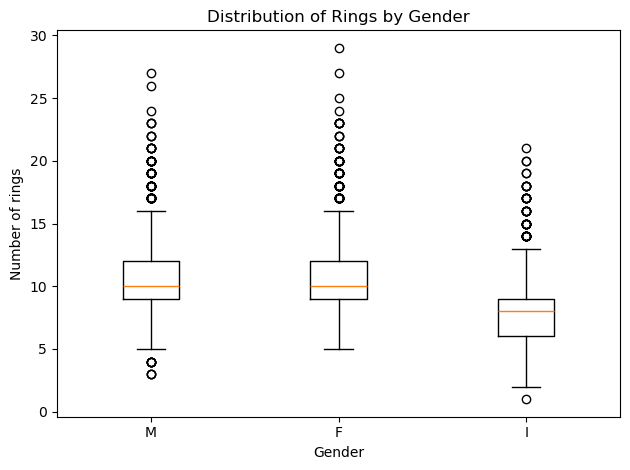

In [48]:
# Influence of gender on rings

sex_categories = df['Sex'].unique()
rings_by_sex = [df[df['Sex'] == sex]['Rings'] for sex in sex_categories]

plt.figure()
title = "Distribution of Rings by Gender"
plt.title(title)
plt.xlabel("Gender")
plt.ylabel("Number of rings")
plt.boxplot(rings_by_sex, labels=sex_categories)
plt.tight_layout()
plt_name = re.sub(r'[^\w\.]', '_', title)
plt.savefig(f"Figures/{plt_name}.png")
plt.show()

In [49]:
# Basic statistics

stats_by_sex = {
    sex: {
        "Mean": np.mean(rings),
        "Median": np.median(rings),
        "Standard Deviation": np.std(rings, ddof=1),
        "Min": np.min(rings),
        "Max": np.max(rings),
        "Q1 (25th Percentile)": np.percentile(rings, 25),
        "Q3 (75th Percentile)": np.percentile(rings, 75),
        "IQR (Q3 - Q1)": np.percentile(rings, 75) - np.percentile(rings, 25)
    }
    for sex, rings in zip(sex_categories, rings_by_sex)
}

stats_df = pd.DataFrame(stats_by_sex).T
display(stats_df)

,Mean,Median,Standard Deviation,Min,Max,Q1 (25th Percentile),Q3 (75th Percentile),IQR (Q3 - Q1)
M,10.705959,10.0,3.027287,3.0,27.0,9.0,12.0,3.0
F,11.131700,10.0,3.104236,5.0,29.0,9.0,12.0,3.0
I,7.891791,8.0,2.512896,1.0,21.0,6.0,9.0,3.0


In [50]:
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(df[df['Sex'] == 'M']['Rings'], 
                           df[df['Sex'] == 'F']['Rings'],
                           df[df['Sex'] == 'I']['Rings'])
print("F-statistic:", f_stat, "p-value:", p_value)

F-statistic: 498.51092093663965 p-value: 7.54491881959999e-195


In [51]:
from itertools import combinations
from scipy.stats import ttest_ind

# Get all possible pairs of Sex categories
sex_pairs = list(combinations(sex_categories, 2))

# Pairwise t-tests
pairwise_results = {}
for sex1, sex2 in sex_pairs:
    t_stat, p_value = ttest_ind(df[df['Sex'] == sex1]['Rings'], 
                                df[df['Sex'] == sex2]['Rings'], 
                                equal_var=False)  # Welch’s t-test for unequal variance
    pairwise_results[f"{sex1} vs {sex2}"] = {"t-statistic": t_stat, "p-value": p_value}

pairwise_df = pd.DataFrame(pairwise_results).T
display(pairwise_df)


,t-statistic,p-value
M vs F,-3.680573,2.371960e-04
M vs I,27.187765,5.886721e-145
F vs I,29.464808,4.106425e-164


In [52]:
def cohens_d(group1, group2):
    return (np.mean(group1) - np.mean(group2)) / ((np.std(group1, ddof=1) + np.std(group2, ddof=1)) / 2)

from itertools import combinations

effect_sizes = {f"{s1} vs {s2}": cohens_d(df[df['Sex'] == s1]['Rings'], df[df['Sex'] == s2]['Rings']) 
                for s1, s2 in combinations(df['Sex'].unique(), 2)}

display(effect_sizes)

{'M vs F': -0.1388693950279859,
 'M vs I': 1.0159117466225778,
 'F vs I': 1.1535811855006952}

The statistics show that gender has a strong influence on the the number of rings on a trutle.

In [53]:
pairwise_table = pd.concat([pairwise_df.T, pd.DataFrame([effect_sizes])])
pairwise_table = pairwise_table.rename(index={0: "Cohen's d"})

def less_than001(x):
    if isinstance(x, float):
        if x < 0.001 and x > -0.001:
            return r"\textless{}0.001"
    return x

pairwise_table = pairwise_table.applymap(less_than001)
display(pairwise_table)

print(pairwise_table.to_latex(float_format="%.3f", caption="Statistical comparisons of number of rings between genders", label="tab:gender_comparisons"))

/var/folders/gl/k4lymyds459_r2rf7dsm8hm80000gn/T/ipykernel_72763/1151136431.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pairwise_table = pairwise_table.applymap(less_than001)


,M vs F,M vs I,F vs I
t-statistic,-3.680573,27.187765,29.464808
p-value,\textless{}0.001,\textless{}0.001,\textless{}0.001
Cohen's d,-0.138869,1.015912,1.153581


\begin{table}
\caption{Statistical comparisons of number of rings between genders}
\label{tab:gender_comparisons}
\begin{tabular}{llll}
\toprule
 & M vs F & M vs I & F vs I \\
\midrule
t-statistic & -3.681 & 27.188 & 29.465 \\
p-value & \textless{}0.001 & \textless{}0.001 & \textless{}0.001 \\
Cohen's d & -0.139 & 1.016 & 1.154 \\
\bottomrule
\end{tabular}
\end{table}



## Regression

### Splitting data

In [54]:
# from sklearn.preprocessing import StandardScaler

# One hot encode gender
X_ohe = pd.get_dummies(X, columns=['Sex'], dtype=int)

models = pd.DataFrame(columns=["Molel", "Hyperparameters", "MSE", "MAE", "R2"])
# Scale data
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_ohe)

# X_less = X_ohe[["Diameter", "Shell weight", "Height", "Sex_I"]]

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer

bin_discretizer = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy='quantile')
binns = bin_discretizer.fit_transform(y.values.reshape(-1,1))

X_train, X_temp, y_train, y_temp, binns_train, binns_temp = train_test_split(X_ohe, y, binns, test_size=0.2, stratify=binns, random_state=1)
X_val, X_test, y_val, y_test, binns_val, binns_test = train_test_split(X_temp, y_temp, binns_temp, test_size=0.5, stratify=binns_temp, random_state=1)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

# Ensure that proportion of bins is preserved across the sets
for bin in (binns_train, binns_val, binns_test):
    unique_vaules, counts = np.unique(bin, return_counts=True)
    print(*zip(unique_vaules, counts/len(bin)))

(3338, 10)
(417, 10)
(418, 10)
(0.0, 0.10724985020970641) (1.0, 0.22917914919113241) (2.0, 0.16506890353505094) (3.0, 0.26842420611144396) (4.0, 0.23007789095266626)
(0.0, 0.10551558752997602) (1.0, 0.2302158273381295) (2.0, 0.16546762589928057) (3.0, 0.2685851318944844) (4.0, 0.2302158273381295)
(0.0, 0.1076555023923445) (1.0, 0.22966507177033493) (2.0, 0.16507177033492823) (3.0, 0.2679425837320574) (4.0, 0.22966507177033493)


In [56]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_test)

mse = mean_squared_error(y_test, y_dummy_pred)
mae = mean_absolute_error(y_test, y_dummy_pred)
r2 = r2_score(y_test, y_dummy_pred)
print("MSE: ", mse)
print("MAE: ", mae)
print("R2: ", r2)

# models.loc[len(models)] = ["Dummy Regressior", "strategy=mean", mse, mae, r2]

MSE:  10.692016584483667
MAE:  2.384877917327225
R2:  -1.5553937746659585e-06


### Linear regression

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_pred = {}
y_pred_all = {}

simple_regressor = LinearRegression()
simple_regressor.fit(X_train, y_train)

# Prediction on validation set
y_pred_lin = simple_regressor.predict(X_val)
mse_val = mean_squared_error(y_val, y_pred_lin)
mae_val = mean_absolute_error(y_val, y_pred_lin)
r2_val = r2_score(y_val, y_pred_lin)
print("val MSE: ", mse_val)
print("val MAE: ", mae_val)
print("val R2: ", r2_val, "\n")

# Prediction on test
y_pred_lin = simple_regressor.predict(X_test)
y_pred["Linear regression"] = y_pred_lin
y_pred_all["Linear regression"] = y_pred_lin
mse = mean_squared_error(y_test, y_pred_lin)
mae = mean_absolute_error(y_test, y_pred_lin)
r2 = r2_score(y_test, y_pred_lin)
print("MSE: ", mse)
print("MAE: ", mae)
print("R2: ", r2)
y_var = y.var()
print("Variance of target: ", y_var)
models.loc[len(models)] = ["Linear Regression", None, mse, mae, r2]

val MSE:  4.34454049525787
val MAE:  1.491332368602845
val R2:  0.5461925389913238 

MSE:  5.269333769205551
MAE:  1.6333112268237546
R2:  0.5071704272567814
Variance of target:  10.399726681982218


### Polynomial regression

In [58]:
from sklearn.preprocessing import PolynomialFeatures

best_mse = None

for i in range(2,6):
    poly = PolynomialFeatures(degree=i, include_bias=False)

    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)
    
    regressor = LinearRegression()
    regressor.fit(X_train_poly, y_train)

    val_pred = regressor.predict(X_val_poly)
    val_mse = mean_squared_error(y_val, val_pred)


    print("Degree: ", i)
    print("Example: ", *zip(y_val[:5], val_pred[:5]))
    print("MSE: ", val_mse)

    """
    poly_train_y_predict = regressor.predict(X_train_poly)
    poly_train_mse = mean_squared_error(y_train, poly_train_y_predict)
    
    X_test_poly = poly.transform(X_test)
    poly_test_y_predict = regressor.predict(X_test_poly)
    poly_test_mse = mean_squared_error(y_test, poly_test_y_predict)
    print("Train MSE: ", poly_train_mse)
    print("Test MSE: ", poly_test_mse)
    """


    name = "Polynomial regression (degree = " + str(i) + ")"
    
    X_test_poly = poly.transform(X_test)
    y_pred_all[name] = regressor.predict(X_test_poly)

    if best_mse is None or val_mse < best_mse:
        best_degree = i
        best_mse = val_mse
        best_model = regressor
        best_transform = poly
        best_name = name

    # Log model
    X_test_poly = poly.transform(X_val)
    y_test_pred = regressor.predict(X_test_poly)
    mse = mean_squared_error(y_val, y_test_pred)
    mae = mean_absolute_error(y_val, y_test_pred)
    r2 = r2_score(y_val, y_test_pred)


y_pred[best_name] = y_pred_all[best_name]

X_test_poly = best_transform.transform(X_test)
y_test_pred = best_model.predict(X_test_poly)
# y_pred["Polynomial regression (degree 2)"] = y_test_pred
mse = mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)
models.loc[len(models)] = ["Polynomial Regression", f"degree={i}", mse, mae, r2]


print("\nBest Degree: ", best_degree)
print("MSE: ", mse)
print("MAE: ", mae)
print("R2: ", r2)


Degree:  2
Example:  (8, 9.951629855598426) (13, 18.58935864261511) (13, 12.753163842582655) (11, 12.627164391501243) (9, 9.175484768035876)
MSE:  4.05498918652522
Degree:  3
Example:  (8, 9.584566080842986) (13, 19.541505784311166) (13, 12.664889708082764) (11, 12.384935375283103) (9, 9.247277650787819)
MSE:  5.5765273414186245
Degree:  4
Example:  (8, 9.858081792995407) (13, 16.982779767681976) (13, 9.924445912708805) (11, 12.043417759848424) (9, 9.04560559422437)
MSE:  60.75074851362047
Degree:  5
Example:  (8, 10.975114042923963) (13, -42.131355336443846) (13, 9.040023732771772) (11, 16.031471464275057) (9, 9.1616212580862)
MSE:  14134.576213640546

Best Degree:  2
MSE:  4.6589069784160175
MAE:  1.507512156283044
R2:  0.5642623458317508


In [59]:
from sklearn.neighbors import KNeighborsRegressor

best_mse_knn = None

for i in [1,3,6,10]:

    knn = KNeighborsRegressor(n_neighbors=i)
    knn.fit(X_train, y_train)

    val_pred = knn.predict(X_val)
    val_mse = mean_squared_error(y_val, val_pred)
    

    print("K: ", i)
    print("Example: ", *zip(y_val[:5], val_pred[:5]))
    print("MSE: ", val_mse)

    """
    y_train_pred = knn.predict(X_train)
    train_mse = mean_squared_error(y_train, y_train_pred)

    print("Train MSE: ", train_mse)
    test_y_predict = knn.predict(X_test)
    test_mse = mean_squared_error(y_test, test_y_predict)
    print("Test MSE: ", test_mse)
    """

    name = "KNN (k = " + str(i) + ")"
    y_pred_all[name] = knn.predict(X_test)
    if best_mse_knn is None or val_mse < best_mse_knn:
        best_k = i
        best_mse_knn = val_mse
        best_knn_model = knn
        best_name = name

    # Log model
    y_test_pred = knn.predict(X_val)
    mse = mean_squared_error(y_val, y_test_pred)
    mae = mean_absolute_error(y_val, y_test_pred)
    r2 = r2_score(y_val, y_test_pred)



y_pred[best_name] = y_pred_all[best_name]

y_test_pred = best_knn_model.predict(X_test)
mse = mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)
models.loc[len(models)] = ["KNN", f"k={best_k}", mse, mae, r2]

print("\nBest k: ", best_k)
print("MSE: ", mse)
print("MAE: ", mae)
print("R2: ", r2)


K:  1
Example:  (8, 16.0) (13, 16.0) (13, 13.0) (11, 11.0) (9, 13.0)
MSE:  7.597122302158273
K:  3
Example:  (8, 12.0) (13, 18.333333333333332) (13, 11.666666666666666) (11, 11.666666666666666) (9, 10.0)
MSE:  5.052224886757262
K:  6
Example:  (8, 10.166666666666666) (13, 18.333333333333332) (13, 10.666666666666666) (11, 11.333333333333334) (9, 9.5)
MSE:  4.385891286970423
K:  10
Example:  (8, 10.0) (13, 16.6) (13, 11.0) (11, 11.6) (9, 9.7)
MSE:  4.499304556354916

Best k:  6
MSE:  4.881379585326953
MAE:  1.505980861244019
R2:  0.5434549563944489


### Model comparison plot


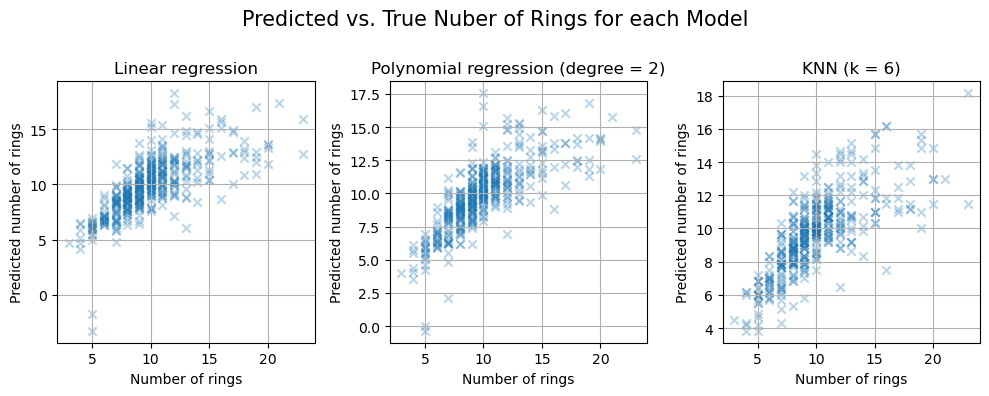

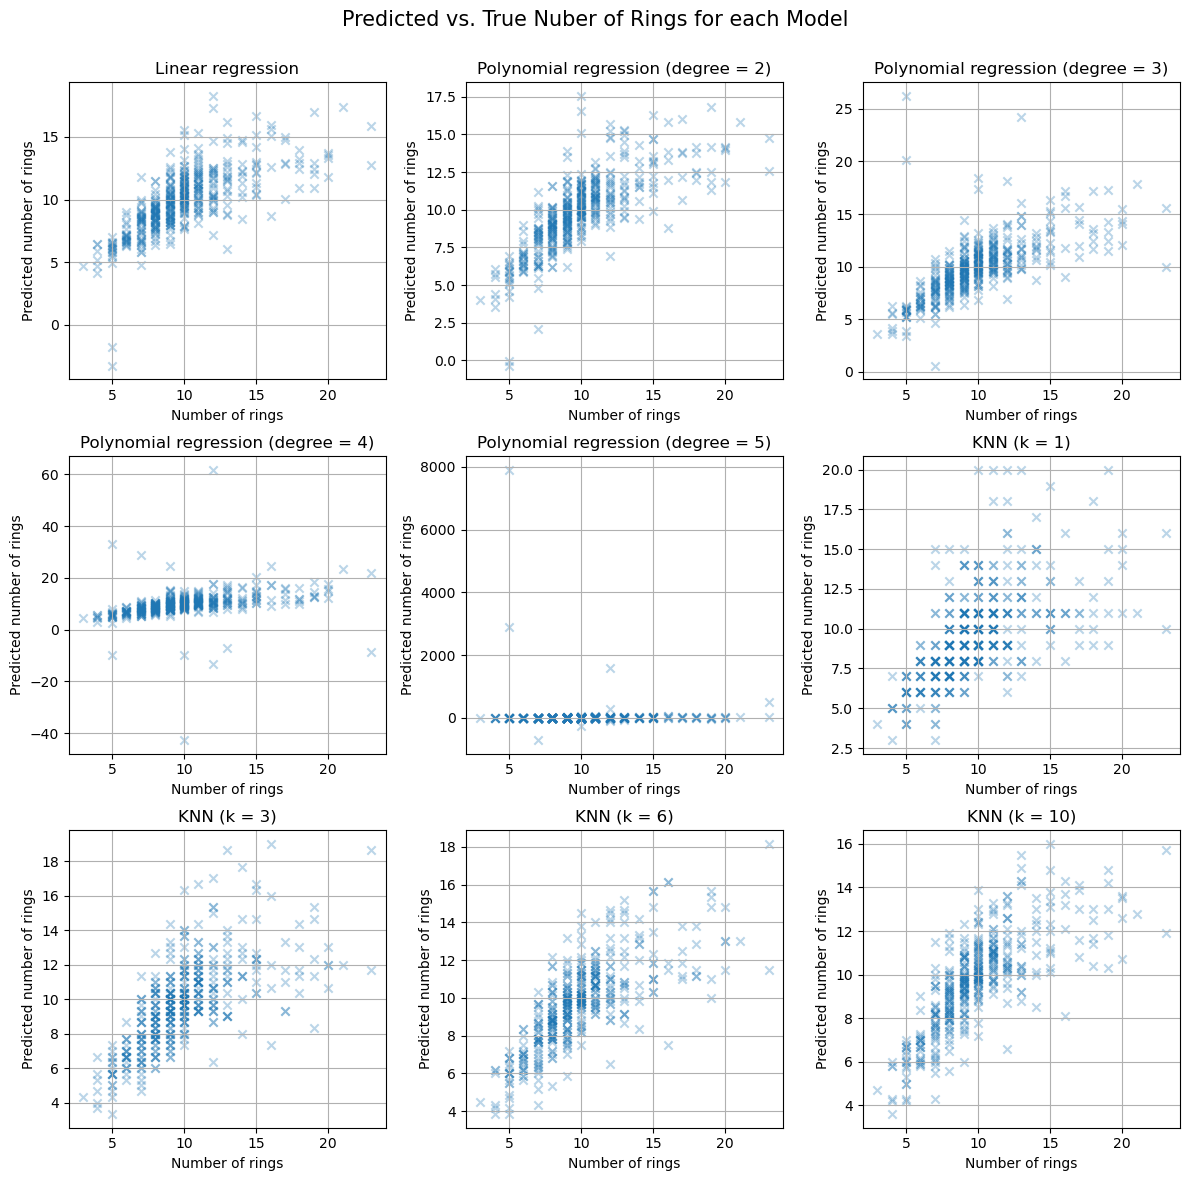

In [60]:
model_num = len(y_pred.keys())  + 1
rows, cols = (1, 3)
fig, axes = plt.subplots(rows, cols, figsize=(10, 4))
axes = axes.flatten()



for ax, (y_true, y_pr, name) in zip(axes, zip([y_test] * len(y_pred.keys()), y_pred.values(), y_pred.keys())):
    ax.scatter(y_true, y_pr, alpha=0.3, marker='x')
    ax.set_ylabel("Predicted number of rings")
    ax.set_xlabel("Number of rings")
    ax.set_title(name)
    ax.grid(True)

# axes[model_num-1].set_visible(False)

title = "Predicted vs. True Nuber of Rings for each Model"
plt.suptitle(title, fontsize=15)
plt.tight_layout()
plt.subplots_adjust(top=0.8)
plt_name = re.sub(r'[^\w\.]', '_', title)
plt.savefig(f"Figures/{plt_name}.png")
plt.show()

model_num = len(y_pred.keys())  + 1
rows, cols = (3, 3)
fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
axes = axes.flatten()


for ax, (y_true, y_pr, name) in zip(axes, zip([y_test] * len(y_pred_all.keys()), y_pred_all.values(), y_pred_all.keys())):
    ax.scatter(y_true, y_pr, alpha=0.3, marker='x')
    ax.set_ylabel("Predicted number of rings")
    ax.set_xlabel("Number of rings")
    ax.set_title(name)
    ax.grid(True)

title = "Predicted vs. True Nuber of Rings for each Model"
plt.suptitle(title, fontsize=15)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt_name = re.sub(r'[^\w\.]', '_', title)
# plt.savefig(f"Figures/{plt_name}.png")
plt.show()

## 10 Fold cross validation

In [61]:
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer

kf = KFold(n_splits=10, shuffle=True, random_state=42)

mse_scores = []
mae_scores = []
r2_scores = []

make_poly = PolynomialFeatures(2, include_bias=False)
lowest_mse = float("inf")
highest_mse = 0

for train_index, test_index in kf.split(X_ohe, y):
    X_train_k_pre, X_test_k_pre = X_ohe.iloc[train_index], X_ohe.iloc[test_index]
    y_train_k, y_test_k = y[train_index], y[test_index]

    X_train_k = make_poly.fit_transform(X_train_k_pre)
    X_test_k = make_poly.transform(X_test_k_pre)

    model = LinearRegression()
    model.fit(X_train_k, y_train_k)
    y_pred_k = model.predict(X_test_k)

    mse = mean_squared_error(y_test_k, y_pred_k)
    mae = mean_absolute_error(y_test_k, y_pred_k)
    r2 = r2_score(y_test_k, y_pred_k)
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)

    if mse < lowest_mse:
        lowest_mse = mse
        best_fold_model = model
        features = make_poly.get_feature_names_out(X_ohe.columns)

    if mse > highest_mse:
        highest_mse = mse
        highest_mae = mae
        worst_r2 = r2
        worst_X_test = X_test_k_pre
        worst_y_pred = y_pred_k
        worst_y_test = y_test_k
        worst_fold_model = model
        worst_poly = poly
        worst_features = make_poly.get_feature_names_out(X_ohe.columns)


print(f"Mean MSE: {np.mean(mse_scores)} ± {np.std(mse_scores)}")
print(f"Mean MAE: {np.mean(mae_scores)} ± {np.std(mae_scores)}")
print(f"Mean R2: {np.mean(r2_scores)} ± {np.std(r2_scores)}")

print("Worst MSE: ", highest_mse)
print("Worst MAE: ", highest_mae)
print("Worst r2: ", worst_r2)

Mean MSE: 4.452030238975195 ± 0.5968254771468757
Mean MAE: 1.4931505367702664 ± 0.0692462289135238
Mean R2: 0.5687005086194357 ± 0.04664991580592013
Worst MSE:  5.823025610198983
Worst MAE:  1.6367216854874973
Worst r2:  0.5173366667309109


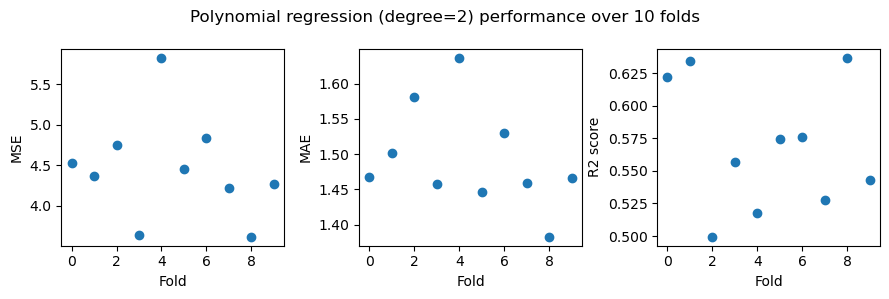

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(9,3))

axes[0].scatter(range(10), mse_scores)
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("MSE")

axes[1].scatter(range(10), mae_scores)
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("MAE")

axes[2].scatter(range(10), r2_scores)
axes[2].set_xlabel("Fold")
axes[2].set_ylabel("R2 score")

title = "Polynomial regression (degree=2) performance over 10 folds"
fig.suptitle(title)
fig.tight_layout()
plt_name = re.sub(r'[^\w\.]', '_', title)
fig.savefig(f"Figures/{plt_name}.png")

Did the same on KNN (out of interest)

In [63]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mse_scores = []
mae_scores = []
r2_scores = []

# make_poly = PolynomialFeatures(include_bias=False)
# X_poly = make_poly.fit_transform(X_ohe)

for train_index, test_index in kf.split(X_ohe, y):
    X_train_k, X_test_k = X_ohe.iloc[train_index], X_ohe.iloc[test_index]
    y_train_k, y_test_k = y[train_index], y[test_index]

    model = KNeighborsRegressor(10)

    model.fit(X_train_k, y_train_k)
    y_pred_k = model.predict(X_test_k)

    mse_scores.append(mean_squared_error(y_test_k, y_pred_k))
    mae_scores.append(mean_absolute_error(y_test_k, y_pred_k))
    r2_scores.append(r2_score(y_test_k, y_pred_k))


print(f"Mean MSE: {np.mean(mse_scores)} ± {np.std(mse_scores)}")
print(f"Mean MAE: {np.mean(mae_scores)} ± {np.std(mae_scores)}")
print(f"Mean R2: {np.mean(r2_scores)} ± {np.std(r2_scores)}")

Mean MSE: 4.79321724438631 ± 0.6784656896453193
Mean MAE: 1.5226356522437552 ± 0.08186434075539897
Mean R2: 0.5373554008514275 ± 0.038270981216666895


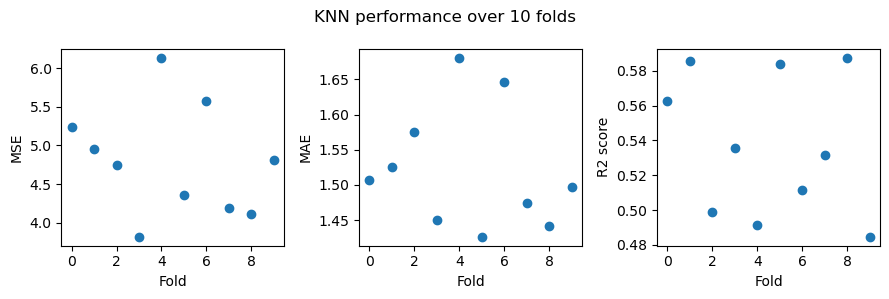

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(9,3))

axes[0].scatter(range(10), mse_scores)
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("MSE")

axes[1].scatter(range(10), mae_scores)
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("MAE")

axes[2].scatter(range(10), r2_scores)
axes[2].set_xlabel("Fold")
axes[2].set_ylabel("R2 score")

title = "KNN performance over 10 folds"
fig.suptitle(title)
fig.tight_layout()
plt_name = re.sub(r'[^\w\.]', '_', title)
fig.savefig(f"Figures/{plt_name}.png")

### Feature importance

In [65]:
weights = best_fold_model.coef_
bias = best_fold_model.intercept_

feature_weight = zip(features, weights)
feature_weight = sorted(feature_weight, key=lambda x: x[1]**2, reverse=True)


display(pd.DataFrame(feature_weight, columns=["Feature", "Weight"])[:10])
display(pd.DataFrame(feature_weight, columns=["Feature", "Weight"])[-5:])
print("Intercept = ", bias)


,Feature,Weight
0,Diameter Height,180.117120
1,Diameter^2,-117.217639
2,Height Shucked weight,-114.396228
3,Height Shell weight,-110.611723
4,Height^2,101.003790
5,Height Viscera weight,-93.116065
6,Length Diameter,79.525893
7,Diameter Shell weight,-76.792991
8,Length^2,-60.291578
9,Diameter Viscera weight,-58.712003


,Feature,Weight
60,Sex_I,0.13271
61,Sex_I^2,0.13271
62,Sex_F Sex_I,0.00000
63,Sex_F Sex_M,0.00000
64,Sex_I Sex_M,0.00000


Intercept =  -0.6493388807664555


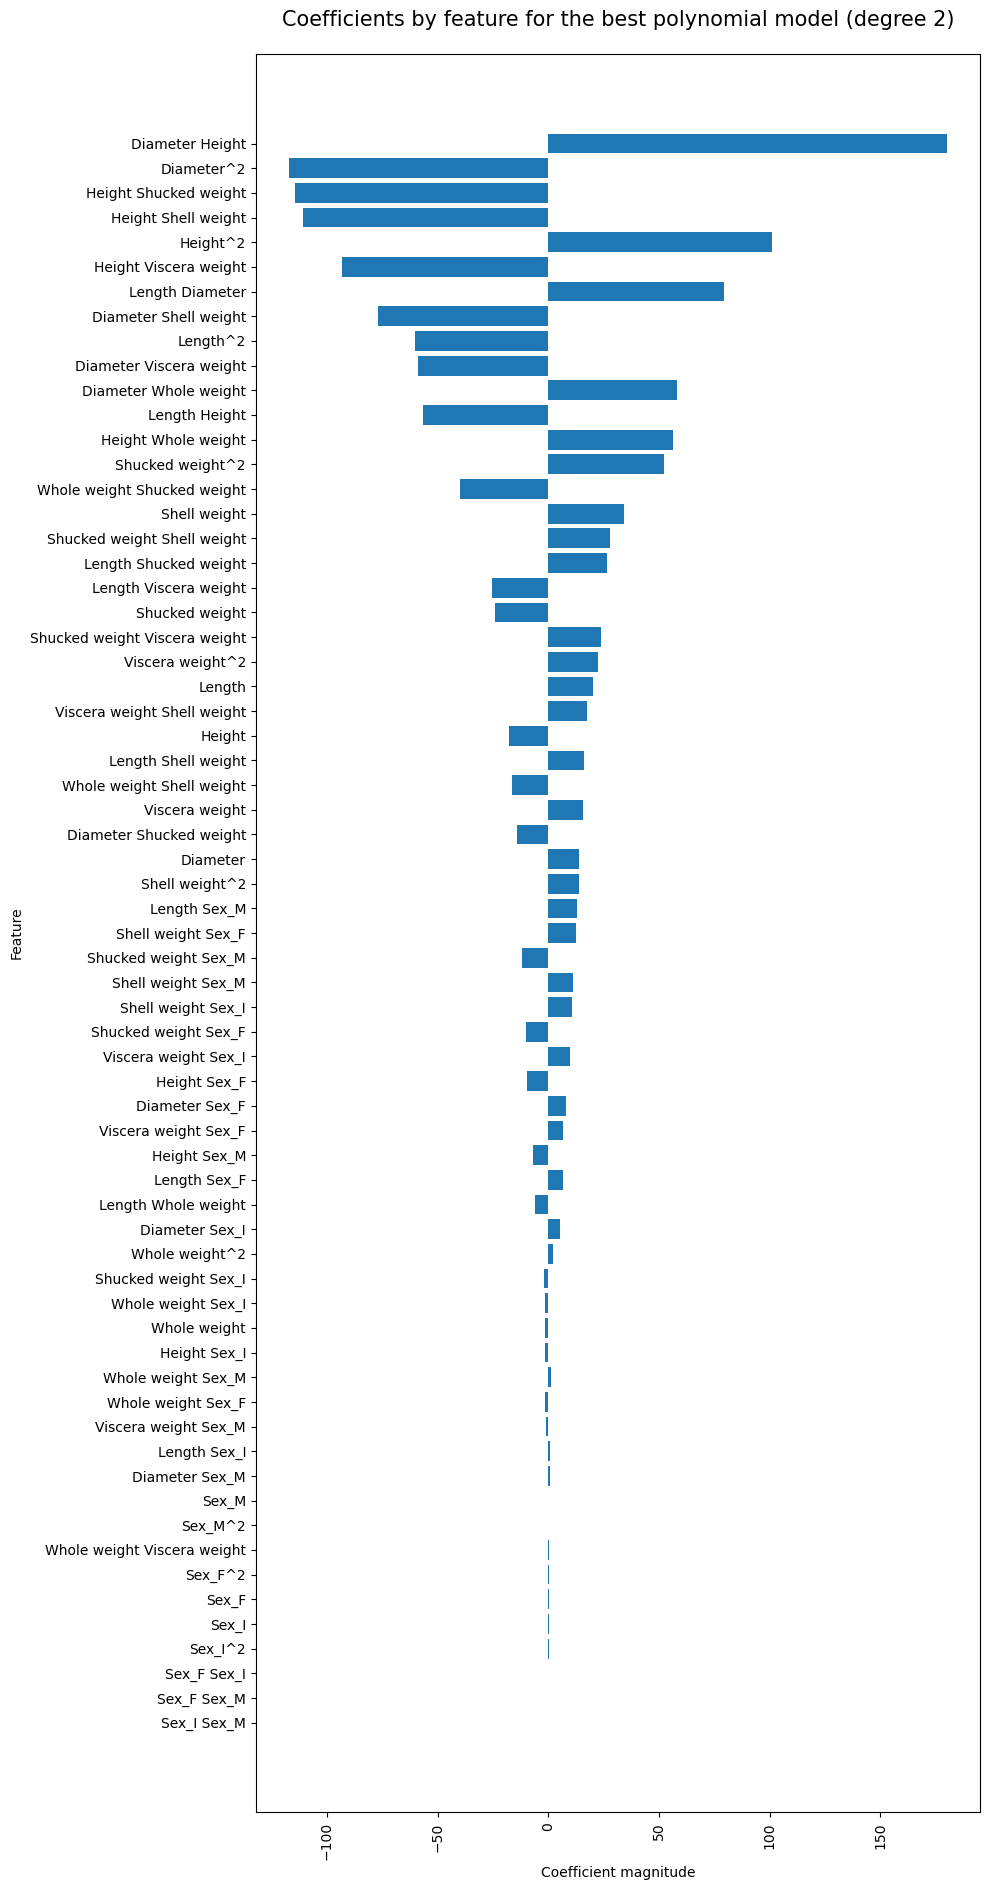

In [66]:
plt.figure(figsize=(10,19))
plt.barh(*zip(*reversed(feature_weight)))
plt.xlabel("Coefficient magnitude")
plt.ylabel("Feature")
title = "Coefficients by feature for the best polynomial model (degree 2)"
plt.title(title, fontsize=15, pad=20)
plt.xticks(rotation=90) 
plt.tight_layout()
plt_name = re.sub(r'[^\w\.]', '_', title)
plt.savefig(f"Figures/{plt_name}.png")
plt.show()



## Investigating errors

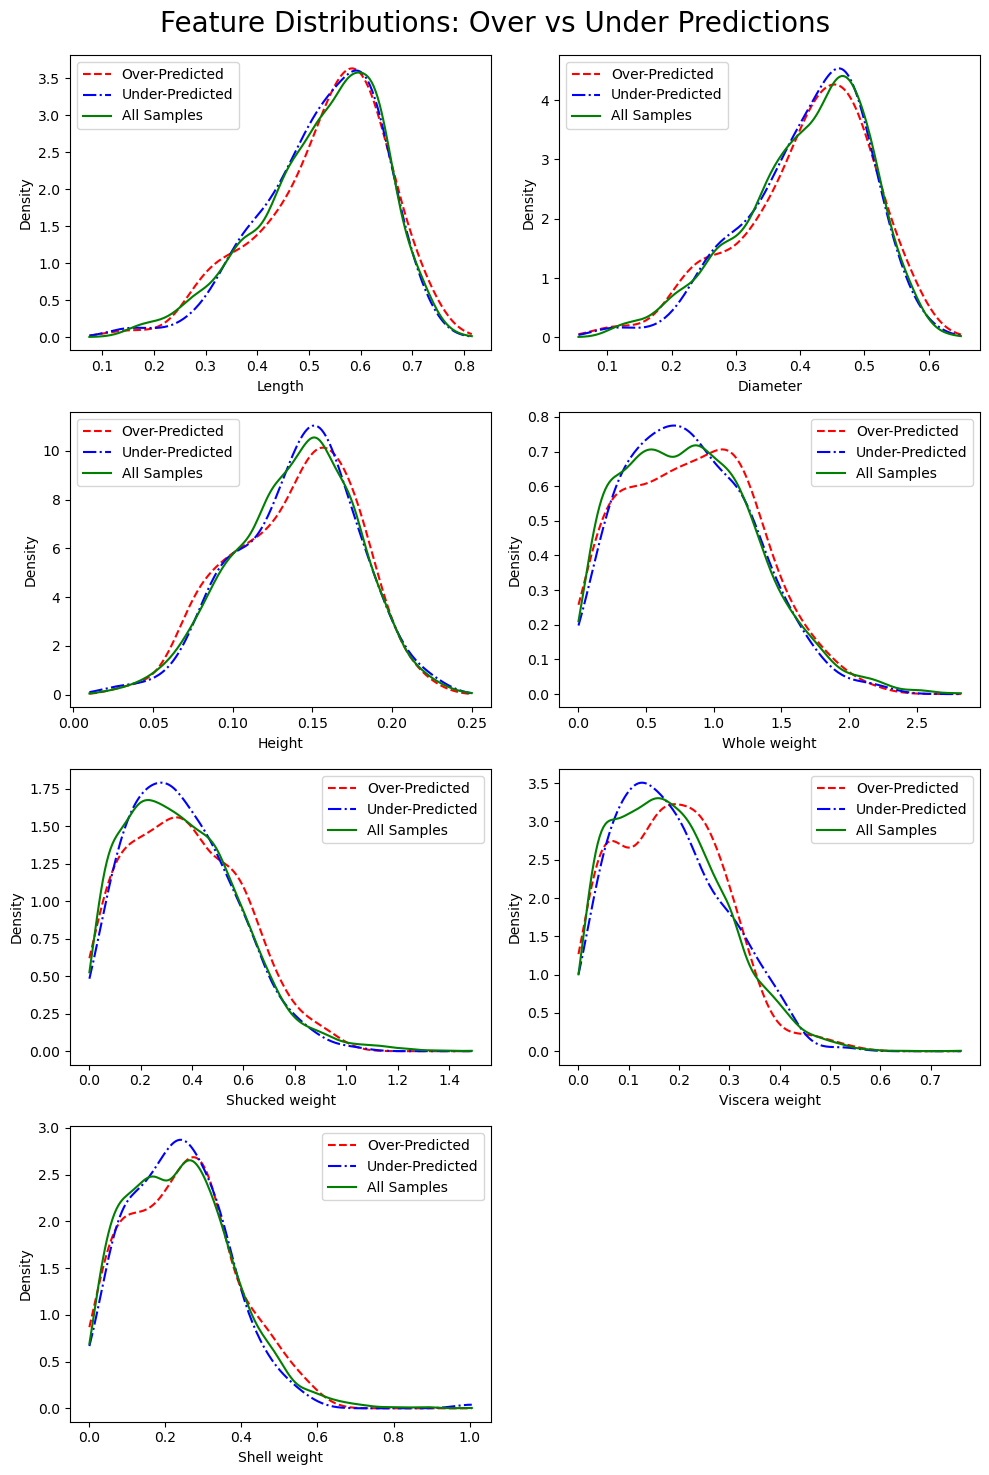

In [67]:
from scipy.stats import gaussian_kde

#print(worst_X_test)

errors = worst_y_test - worst_y_pred

under_predicted = worst_X_test[errors < 0]
over_predicted = worst_X_test[errors > 0]

"""
fig, axes = plt.subplots(5, 2, figsize=(10, 30))
axes = axes.flatten()


for ax, feature in zip(axes, worst_X_test.columns):

    data = [
        over_predicted[feature],
        under_predicted[feature],
        X_ohe[feature]
    ]

    ax.boxplot(data, tick_labels=["Over-Predicted", "Under-Predicted", "All Samples"])
    ax.set_ylabel(feature)
    ax.set_title(feature)

plt.tight_layout()
plt.show()
"""
fig, axes = plt.subplots(4, 2, figsize=(10, 15))
# fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, feature in zip(axes, numerical_features):
    kde_over = gaussian_kde(over_predicted[feature])
    kde_under = gaussian_kde(under_predicted[feature])
    kde_all = gaussian_kde(X_ohe[feature])

    # Create common x-range for all
    x_min = min(X_ohe[feature].min(), over_predicted[feature].min(), under_predicted[feature].min())
    x_max = max(X_ohe[feature].max(), over_predicted[feature].max(), under_predicted[feature].max())
    x = np.linspace(x_min, x_max, 200)

    # Plot density curves
    ax.plot(x, kde_over(x), color="red", linestyle="--", label="Over-Predicted")
    ax.plot(x, kde_under(x), color="blue", linestyle="-.", label="Under-Predicted")
    ax.plot(x, kde_all(x), color="green", linestyle="-", label="All Samples")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()
    
    """
    ax.hist(over_predicted[feature], bins=15, alpha=0.7, color="red", label="Over-Predicted", edgecolor="black", density=True)
    ax.hist(under_predicted[feature], bins=15, alpha=0.7, color="blue", label="Under-Predicted", edgecolor="black", density=True)
    ax.hist(X_ohe[feature], bins=15, alpha=0.7, color="green", label="Under-Predicted", edgecolor="black", density=True)
    ax.set_title(feature)
    ax.legend()
    """

axes[-1].set_visible(False)

title = "Feature Distributions: Over vs Under Predictions"
plt.suptitle(title, fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt_name = re.sub(r'[^\w\.]', '_', title)
plt.savefig(f"Figures/{plt_name}.png")
plt.show()


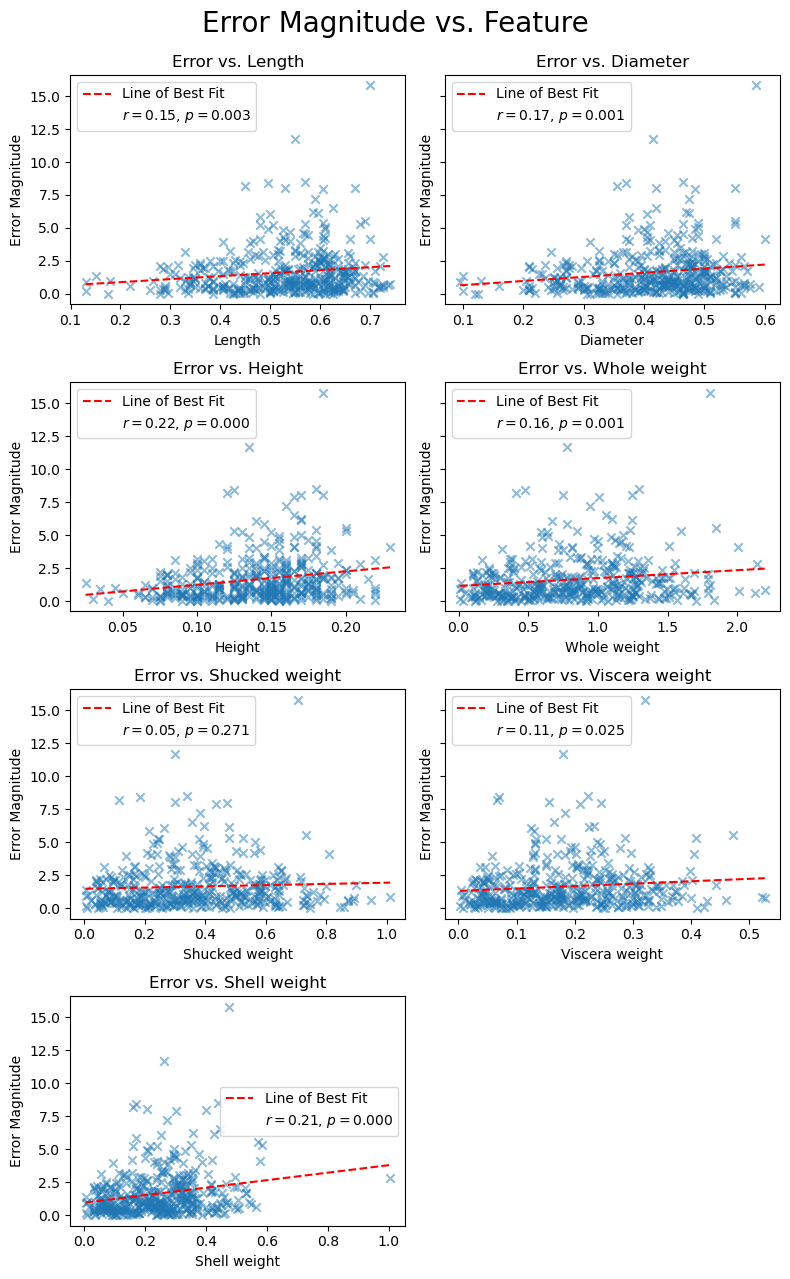

In [68]:
# Error magnitudes
from scipy.stats import linregress

fig, axes = plt.subplots(4, 2, figsize=(8, 13), sharey=True)
# fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.flatten()
for ax, feature in zip(axes, numerical_features):
    x_i = worst_X_test[feature]
    y_i = np.abs(errors)

    ax.scatter(x_i,y_i, alpha=0.5, marker="x")
    
    slope, intercept, r_value, p_value, std_err = linregress(x_i,y_i)
    x_vals = np.linspace(x_i.min(), x_i.max(), 100)
    y_vals = slope * x_vals + intercept
    ax.plot(x_vals, y_vals, color="red", linestyle="--", label="Line of Best Fit")

    # Put r and p in legend
    rp_label = f"$r = {r_value:.2f}$, $p = {p_value:.3f}$"
    ax.plot(x_vals, y_vals, ' ', label=rp_label)

    ax.set_xlabel(feature)
    ax.set_ylabel("Error Magnitude")
    ax.set_title(f"Error vs. {feature}")

    ax.legend()

axes[-1].set_visible(False)

title = "Error Magnitude vs. Feature"
plt.suptitle(title, fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.93)  # Give it breathing 
plt_name = re.sub(r'[^\w\.]', '_', title)
plt.savefig(f"Figures/{plt_name}.png")
plt.show()

## Storing & reporting results

In [69]:
print(models)

models.to_csv("final_model_metrics.csv")

                   Molel Hyperparameters       MSE       MAE        R2
0      Linear Regression            None  5.269334  1.633311  0.507170
1  Polynomial Regression        degree=5  4.658907  1.507512  0.564262
2                    KNN             k=6  4.881380  1.505981  0.543455


In [70]:
print(models.to_latex(float_format="%.3f", caption="Final models", label="tab:model_comparisons"))

\begin{table}
\caption{Final models}
\label{tab:model_comparisons}
\begin{tabular}{lllrrr}
\toprule
 & Molel & Hyperparameters & MSE & MAE & R2 \\
\midrule
0 & Linear Regression & NaN & 5.269 & 1.633 & 0.507 \\
1 & Polynomial Regression & degree=5 & 4.659 & 1.508 & 0.564 \\
2 & KNN & k=6 & 4.881 & 1.506 & 0.543 \\
\bottomrule
\end{tabular}
\end{table}



## Trying other stuff for fun

In [71]:
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer
from sklearn.linear_model import Ridge

kf = KFold(n_splits=10, shuffle=True, random_state=42)

mse_scores = []
mae_scores = []
r2_scores = []

make_poly = PolynomialFeatures(5, include_bias=False)
lowest_mse = float("inf")
highest_mse = 0

for train_index, test_index in kf.split(X_ohe, y):
    X_train_k_pre, X_test_k_pre = X_ohe.iloc[train_index], X_ohe.iloc[test_index]
    y_train_k, y_test_k = y[train_index], y[test_index]

    X_train_k = make_poly.fit_transform(X_train_k_pre)
    X_test_k = make_poly.transform(X_test_k_pre)

    model = Ridge(alpha=1)
    model.fit(X_train_k, y_train_k)
    y_pred_k = model.predict(X_test_k)

    mse = mean_squared_error(y_test_k, y_pred_k)
    mae = mean_absolute_error(y_test_k, y_pred_k)
    r2 = r2_score(y_test_k, y_pred_k)
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)

    if mse < lowest_mse:
        lowest_mse = mse
        best_fold_model = model
        features = make_poly.get_feature_names_out(X_ohe.columns)

    if mse > highest_mse:
        highest_mse = mse
        highest_mae = mae
        worst_r2 = r2
        worst_X_test = X_test_k_pre
        worst_y_pred = y_pred_k
        worst_y_test = y_test_k
        worst_fold_model = model
        worst_poly = poly
        worst_features = make_poly.get_feature_names_out(X_ohe.columns)


print(f"Mean MSE: {np.mean(mse_scores)} ± {np.std(mse_scores)}")
print(f"Mean MAE: {np.mean(mae_scores)} ± {np.std(mae_scores)}")
print(f"Mean R2: {np.mean(r2_scores)} ± {np.std(r2_scores)}")

print("Worst MSE: ", highest_mse)
print("Worst MAE: ", highest_mae)
print("Worst r2: ", worst_r2)

Mean MSE: 4.441311155513157 ± 0.59661793953734
Mean MAE: 1.5026422671639508 ± 0.07035260545786313
Mean R2: 0.5699545290896998 ± 0.04395573813484543
Worst MSE:  5.883477789283182
Worst MAE:  1.6621233062682466
Worst r2:  0.512325860972294
